In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [2]:
CSV_PATH = "archive/data.csv"
IMAGE_DIR = "archive/image"

df = pd.read_csv(CSV_PATH)
image_column = df.columns[0]

df["image_path"] = df[image_column].astype(str).apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpeg")
)

df = df[df["image_path"].apply(os.path.exists)]
print("Total samples:", len(df))

Total samples: 1512


In [3]:
encoder = LabelEncoder()
df["label_encoded"] = encoder.fit_transform(df["classes"])
print("Classes:", encoder.classes_)

Classes: ['bumper_dent' 'bumper_scratch' 'door_dent' 'door_scratch' 'glass_shatter'
 'head_lamp' 'tail_lamp' 'unknown']


In [4]:
IMG_SIZE = 224
images = []
labels = []
for _, row in df.iterrows():
    img = cv2.imread(row["image_path"])
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)
    images.append(img)
    labels.append(row["label_encoded"])

X = np.array(images)
y = np.array(labels)
print("Dataset shape:", X.shape)

Dataset shape: (1512, 224, 224, 3)


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

Train: (1209, 224, 224, 3)
Validation: (151, 224, 224, 3)
Test: (152, 224, 224, 3)


In [6]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)

In [ ]:
base_model = VGG19(
    weights="imagenet",
    include_top=True,
    input_shape=(224,224,3)
)

output = Dense(num_classes, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 59s 1us/step


In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=40,
    callbacks=[early_stop]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,420,424 (77.90 MB)

 Trainable params: 7,475,464 (28.52 MB)

 Non-trainable params: 12,944,960 (49.38 MB)

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.2371 - loss: 2.3735 - val_accuracy: 0.3642 - val_loss: 1.5548
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.3518 - loss: 1.6305 - val_accuracy: 0.3775 - val_loss: 1.4528
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.4026 - loss: 1.5412 - val_accuracy: 0.4437 - val_loss: 1.3913
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.4417 - loss: 1.4268 - val_accuracy: 0.4702 - val_loss: 1.3641
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.4817 - loss: 1.3550 - val_accuracy: 0.5033 - val_loss: 1.2762
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.4997 - loss: 1.3056 - val_accuracy: 0.5298 - val_loss: 1.2325
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.5125 - loss: 1.3029 - val_accuracy: 0.5563 - val_loss: 1.1732
Epoch 8/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.5878 - loss: 1.1417 - val_accuracy: 0.6358 - v

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.8041 - loss: 0.5613

Model Evaluation
----------------------------
Test Loss     : 0.5030
Test Accuracy : 0.8224
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step

Overall Evaluation Metrics
----------------------------
Accuracy  : 0.8224
Precision : 0.8491
Recall    : 0.8224
F1 Score  : 0.8139

Detailed Classification Report
----------------------------
                precision    recall  f1-score   support

   bumper_dent       0.69      0.85      0.76        13
bumper_scratch       1.00      0.12      0.22         8
     door_dent       0.65      0.85      0.74        20
  door_scratch       0.63      0.75      0.69        16
 glass_shatter       1.00      0.92      0.96        13
     head_lamp       0.86      0.92      0.89        13
     tail_lamp       0.86      0.86      0.86        14
       unknown       0.96      0.87      0.91        55

      accuracy                           0.82       152
     macro avg       0.83      0.77      0.

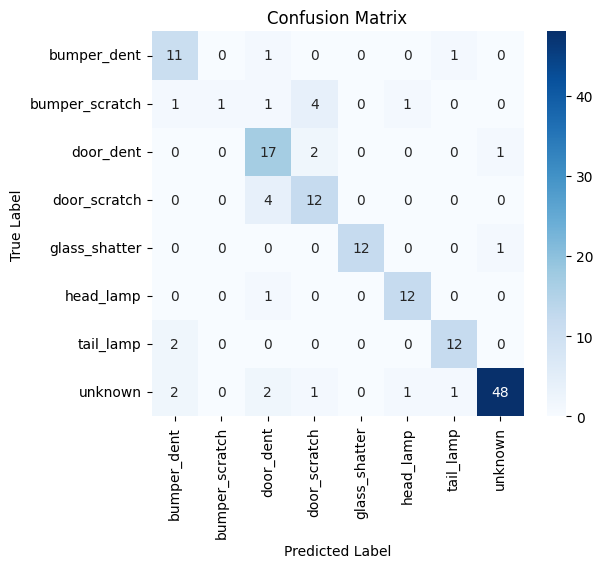

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("\nModel Evaluation")
print("----------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
y_test_labels = encoder.inverse_transform(y_test)
pred_labels = encoder.inverse_transform(pred_classes)

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nOverall Evaluation Metrics")
print("----------------------------")

accuracy = accuracy_score(y_test_labels, pred_labels)
precision = precision_score(y_test_labels, pred_labels, average='weighted')
recall = recall_score(y_test_labels, pred_labels, average='weighted')
f1 = f1_score(y_test_labels, pred_labels, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nDetailed Classification Report")
print("----------------------------")
print(classification_report(y_test_labels, pred_labels))

cm = confusion_matrix(y_test_labels, pred_labels)

print("\nConfusion Matrix")
print("----------------------------")
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()